# Phishing Email Detection with BERT
## Notebook 02 – Model Training

This notebook fine-tunes a BERT-based classifier on the combined email dataset.


### Notebook objectives

- Load the cleaned dataset.
- Tokenize texts using a BERT tokenizer.
- Wrap tokenized data in PyTorch dataset objects.
- Configure and run HuggingFace `Trainer` for fine-tuning.
- Monitor validation performance and save the trained model.


### 1. Imports and configuration

Import libraries, set random seeds, and define core paths.


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from torch.utils.data import Subset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)

import optuna

# Paths and data loading
DATA_DIR = Path("../data")
COMBINED = DATA_DIR / "combined.csv"
assert COMBINED.exists(), f"Missing: {COMBINED}"

df = pd.read_csv(COMBINED)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print(df.shape)
print(df["label"].value_counts())
print(df.columns.tolist())
df.head(10)


2025-11-30 00:49:55.958268: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 00:49:56.291134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-30 00:49:57.771981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(199737, 2)
label
0    107533
1     92204
Name: count, dtype: int64
['text', 'label']


,text,label
0,re:uribl > 71.920 77.1604 1.2331 0.984 0.71 0.00 uribl_black you've always surprised me with your ham rates theo.i'm guessing these are prbly good...,0
1,can you last 36 hours ? mol ci - ialis softabs is better than pfizer viiagrra and normal ci - ialis because:- guaaraantees 36 hours lasting - safe...,1
2,"home delivery cials-tabs ""the beverage.icee, bro.this is what put this place on the map.-- encino man"", ""scientists do it with plenty of research....",1
3,fw:presentation tammie schoppe enron americas-office of the chair assistant to louise kitchen 713.853.4220 office 713.646.8562 fax 713.253.2131 mo...,0
4,good day.what's so good about it?:) [url] grab the broom of anger and drive off the beast of fear.vidimo se [url],1
5,"[pownceapi] re:sets list in new api.i would be interested in at least knowing, what users belong to a set.on mar 17, 7:22 pm, ""leah culver"" wrote:...",0
6,"iraqi kindergarten:smiles and vows to fight may 23, 200705:15 am edt top stories weather u.s.world business sports health technology entertainment...",0
7,"so you wanted another message from nicole, yeah? tired of the same old routine? this is just the solution you've been searching for- the vibrator ...",1
8,"cnn alerts:my custom alert cnn alerts:my custom alert alert name:my custom alert tropical storm approaches texas fri, 8 aug 2008 14:56:56 +0200 fu...",1
9,best online drugs here prohibitory merrymake reprisal wolff contextual bramble budge biscuit gershwin audio need pres cription medication without ...,1


### 2. Create stratified dataset splits

Build and save train/val/test splits while preserving label balance.


In [2]:

cols = ["text", "label"]
df = df[cols].dropna(subset=["text", "label"])

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=2025,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=2025,
    stratify=train_df["label"]
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

train_texts, train_labels = train_df["text"].astype(str).tolist(), train_df["label"].tolist()
val_texts,   val_labels   = val_df["text"].astype(str).tolist(),   val_df["label"].tolist()
test_texts,  test_labels  = test_df["text"].astype(str).tolist(),  test_df["label"].tolist()


Train: 143810 | Val: 15979 | Test: 39948


### 3. Tokenize datasets with BERT tokenizer

Convert raw texts into token IDs with truncation and fixed max length.


In [3]:

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, max_length=256)
val_encodings   = tokenizer(val_texts,   truncation=True, max_length=256)
test_encodings  = tokenizer(test_texts,  truncation=True, max_length=256)


### 4. Dataset wrapper

Create a custom PyTorch `Dataset` that stores tokenized inputs and their 
corresponding labels, and returns them in tensor format for the Trainer.

In [4]:

class EmailDataset(torch.utils.data.Dataset):
    # Initialize dataset wrapper with texts and labels
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    # Return the number of samples in the dataset
    def __len__(self):
        return len(self.labels)

    # Return tokenized features and label for a single example
    def __getitem__(self, idx):

        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


### 5. Prepare train/validation/test datasets

Create dataset splits used for model training and evaluation.


In [5]:

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset   = EmailDataset(val_encodings,   val_labels)
test_dataset  = EmailDataset(test_encodings,  test_labels)

USE_SMALL = False
N_TRAIN_SMALL, N_VAL_SMALL = 10_000, 2_000

# Generate stratified indices for splitting the dataset into train/val/test
def stratified_indices(labels, n_keep, seed=2025):
    all_idx = np.arange(len(labels))
    keep_idx, _ = train_test_split(
        all_idx, train_size=n_keep, random_state=seed,
        shuffle=True, stratify=labels
    )
    return keep_idx

if USE_SMALL:
    tr_idx = stratified_indices(np.array(train_labels), min(N_TRAIN_SMALL, len(train_labels)))
    va_idx = stratified_indices(np.array(val_labels),   min(N_VAL_SMALL,   len(val_labels)))
    train_dataset_small = Subset(train_dataset, tr_idx)
    val_dataset_small   = Subset(val_dataset,   va_idx)
    final_train_ds, final_val_ds = train_dataset_small, val_dataset_small
else:
    final_train_ds, final_val_ds = train_dataset, val_dataset

print(f"Train used: {len(final_train_ds)} | Val used: {len(final_val_ds)} | Test: {len(test_dataset)}")


Train used: 143810 | Val used: 15979 | Test: 39948


### 6. Load pre-trained BERT model

In [6]:

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 7. Metric computation

Define the metrics function passed to the Trainer to compute accuracy and F1.


In [7]:

# Compute evaluation metrics such as accuracy, precision, recall and F1
def compute_metrics(eval_pred):

    if hasattr(eval_pred, "predictions"):
        logits = eval_pred.predictions
        labels = eval_pred.label_ids
    else:
        logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


### 8. Model initialization and Training arguments

Provide a factory function that builds a new BERT classification model.

Configure training hyperparameters such as batch size, learning rate, and epochs.



In [8]:

# Create a new BERT classification model instance with default hyperparameters
def model_init(trial=None):

    dr = trial.suggest_float("dropout", 0.1, 0.5) if trial is not None else 0.1
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2,
        hidden_dropout_prob=dr,
        attention_probs_dropout_prob=dr,
    )

training_args_hpo = TrainingArguments(
    output_dir="./results_tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_tuned",
    report_to=[],
    seed=2025,
)

hpo_train_ds = final_train_ds
hpo_val_ds   = final_val_ds

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_hpo = Trainer(
    model_init=model_init,
    args=training_args_hpo,
    train_dataset=hpo_train_ds,
    eval_dataset=hpo_val_ds,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


/tmp/ipykernel_2341/966491846.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_hpo = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 9. Load or create Optuna study

Load the existing Optuna study from SQLite or create a new one and list completed trials.


In [9]:

db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning_full.db")
study_name = "bert_tuning_full"

os.makedirs(os.path.dirname(db_path), exist_ok=True)
print("DB path:", db_path)

try:
    study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")
    print(f"Loaded existing study: '{study_name}' with {len(study.trials)} trials.")
except KeyError:
    print(f"Study '{study_name}' not found. Creating a new one...")
    study = optuna.create_study(study_name=study_name, storage=f"sqlite:///{db_path}", direction="maximize")
    print(f"New study '{study_name}' created at {db_path}.")

print(f"\nFinished trials: {len(study.trials)}")
for t in study.trials:
    print(f"Trial {t.number}: value={t.value}, params={t.params}")


DB path: /home/nmd/projects/phishing-detector/notebooks/tuning_checkpoints/bert_tuning_full.db
Loaded existing study: 'bert_tuning_full' with 4 trials.

Finished trials: 4
Trial 0: value=0.9845816487356952, params={'learning_rate': 1.826222907426669e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 16, 'weight_decay': 0.10631544814686143, 'dropout': 0.3098949027144738}
Trial 1: value=0.9480459159976113, params={'learning_rate': 0.00013475573346957226, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'weight_decay': 0.28800402966401933, 'dropout': 0.1615724039236692}
Trial 2: value=0.9733987424860084, params={'learning_rate': 1.3288929021561388e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.01071425192460672, 'dropout': 0.49788967026423336}
Trial 3: value=0.6316420466709484, params={'learning_rate': 0.000111432326842062, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.2643761433867896, 'dropout': 0.4392628393

### 10. Hyperparameter tuning with Optuna

Run an Optuna study to find the best BERT training hyperparameters.

Skip to cell 11 if you don't want to retrain and already have some trials from previous trainings.


In [10]:

db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning_full.db")

# Define the Optuna hyperparameter search space for BERT training
def optuna_hp_space(trial):
    return {

        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 5),
        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3),
    }

best_run = trainer_hpo.hyperparameter_search(
    direction="maximize",
    compute_objective=lambda m: m["eval_f1"],
    backend="optuna",
    n_trials=2,
    hp_space=optuna_hp_space,
    study_name="bert_tuning_full",
    storage=f"sqlite:///{db_path}",
    load_if_exists=True,
)

print("Best hyperparameters found:")
print(best_run.hyperparameters)


[I 2025-11-30 00:55:11,680] Using an existing study with name 'bert_tuning_full' instead of creating a new one.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.698800,0.684120,0.538394,0.000000,0.000000,0.000000
2,0.691900,0.690208,0.538394,0.000000,0.000000,0.000000
3,0.100200,0.135291,0.969898,0.970520,0.964073,0.967286


[I 2025-11-30 03:00:05,955] Trial 4 finished with value: 0.9672855879752431 and parameters: {'learning_rate': 7.266153871793818e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.1408995590542748, 'dropout': 0.24267528392545953}. Best is trial 0 with value: 0.9845816487356952.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.695900,0.703783,0.461606,0.461606,1.000000,0.631642
2,0.694200,0.692214,0.538394,0.000000,0.000000,0.000000
3,0.693300,0.691657,0.538394,0.000000,0.000000,0.000000


[I 2025-11-30 05:00:01,366] Trial 5 pruned. 


Best hyperparameters found:
{'learning_rate': 1.826222907426669e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 16, 'weight_decay': 0.10631544814686143, 'dropout': 0.3098949027144738}


### 11. Print out finished trials

Print out finished trials just for checking

In [11]:

print(f"\nFinished trials: {len(study.trials)}")
for t in study.trials:
    print(f"Trial {t.number}: value={t.value}, params={t.params}")



Finished trials: 6
Trial 0: value=0.9845816487356952, params={'learning_rate': 1.826222907426669e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 16, 'weight_decay': 0.10631544814686143, 'dropout': 0.3098949027144738}
Trial 1: value=0.9480459159976113, params={'learning_rate': 0.00013475573346957226, 'num_train_epochs': 3, 'per_device_train_batch_size': 32, 'weight_decay': 0.28800402966401933, 'dropout': 0.1615724039236692}
Trial 2: value=0.9733987424860084, params={'learning_rate': 1.3288929021561388e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.01071425192460672, 'dropout': 0.49788967026423336}
Trial 3: value=0.6316420466709484, params={'learning_rate': 0.000111432326842062, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.2643761433867896, 'dropout': 0.4392628393926302}
Trial 4: value=0.9672855879752431, params={'learning_rate': 7.266153871793818e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'we

### 12. Retrieve best Optuna hyperparameters

Load the study and display the best hyperparameters and F1 score.


In [12]:

db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning_full.db")

study = optuna.load_study(
    study_name="bert_tuning_full",
    storage=f"sqlite:///{db_path}"
)

best_params = study.best_params
best_value = study.best_value

print("Best hyperparameters found:", best_params)
print(f"Best F1 score: {best_value:.4f}")


Best hyperparameters found: {'learning_rate': 1.826222907426669e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 16, 'weight_decay': 0.10631544814686143, 'dropout': 0.3098949027144738}
Best F1 score: 0.9846


### 13. Configure tuned TrainingArguments and initialize final model

Build the final training configuration using Optuna’s best parameters and initialize a 
BERT model with tuned dropout settings.


In [13]:

training_args_best = TrainingArguments(
    output_dir="./results_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    learning_rate=best_params["learning_rate"],
    num_train_epochs=int(best_params["num_train_epochs"]),
    per_device_train_batch_size=int(best_params["per_device_train_batch_size"]),
    per_device_eval_batch_size=max(32, 2*int(best_params["per_device_train_batch_size"])),
    weight_decay=float(best_params["weight_decay"]),
    warmup_ratio=0.1,
    lr_scheduler_type="linear",

    logging_dir="./logs_final",
    report_to=[],
    seed=2025,
)

tuned_dropout = float(best_params.get("dropout", 0.1))

# Create a BERT model with the best Optuna hyperparameters
def model_init_best():
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2,
        hidden_dropout_prob=tuned_dropout,
        attention_probs_dropout_prob=tuned_dropout,
    )

final_train_for_fit = train_dataset
final_val_for_fit   = val_dataset

tuned_trainer = Trainer(
    model_init=model_init_best,
    args=training_args_best,
    train_dataset=final_train_for_fit,
    eval_dataset=final_val_for_fit,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


/tmp/ipykernel_2341/3391942268.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  tuned_trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 14. Train model and Evaluation

Run fine-tuning and log training/validation metrics.

Evaluate the trained model on the validation or test split.


In [14]:

train_out_final = tuned_trainer.train()
print(train_out_final)

FINAL_DIR = Path("../models/saved_model")
FINAL_DIR.mkdir(parents=True, exist_ok=True)
tuned_trainer.save_model(str(FINAL_DIR))
tokenizer.save_pretrained(str(FINAL_DIR))

trainer = tuned_trainer

test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.078500,0.209979,0.960573,0.995738,0.918520,0.955571
2,0.053900,0.062785,0.986482,0.993793,0.976817,0.985232
3,0.028600,0.163154,0.971275,0.996697,0.940889,0.967989
4,0.014500,0.157203,0.975843,0.997014,0.950515,0.973209
5,0.012900,0.113904,0.983103,0.995952,0.967326,0.981431


TrainOutput(global_step=44945, training_loss=0.050747372812603615, metrics={'train_runtime': 12450.9317, 'train_samples_per_second': 57.751, 'train_steps_per_second': 3.61, 'total_flos': 9.459343790085768e+16, 'train_loss': 0.050747372812603615, 'epoch': 5.0})


Test Results: {'eval_loss': 0.06229381263256073, 'eval_accuracy': 0.9866576549514369, 'eval_precision': 0.9940955744399073, 'eval_recall': 0.9768993004717749, 'eval_f1': 0.9854224215737221, 'eval_runtime': 206.3639, 'eval_samples_per_second': 193.58, 'eval_steps_per_second': 6.052, 'epoch': 5.0}


### 15. Final test evaluation and confusion matrix visualization

Evaluate the tuned model on the test set and save metrics and confusion matrices.


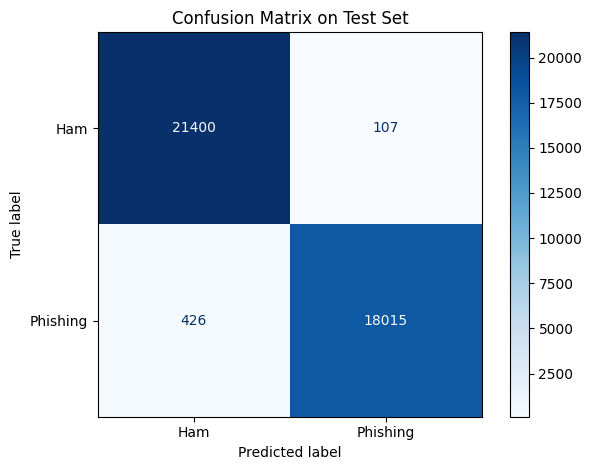

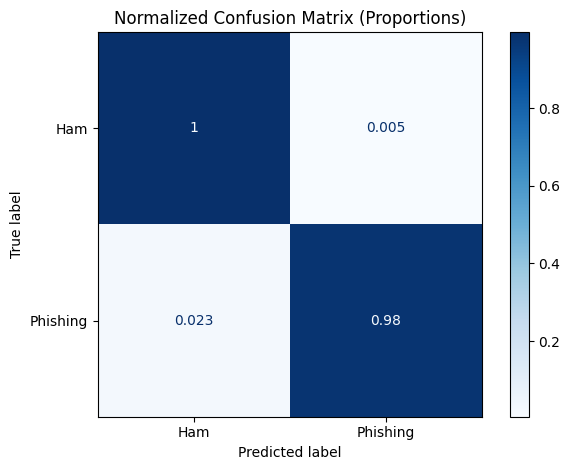

In [15]:

po = trainer.predict(test_dataset)
logits = po.predictions
labels = po.label_ids
preds = np.argmax(logits, axis=-1)

OUT = Path("../notebooks")
OUT.mkdir(parents=True, exist_ok=True)
results = {"eval_samples": int(len(labels))}

report = classification_report(labels, preds,
                               target_names=["Ham", "Phishing"],
                               output_dict=True)
results.update(report)

with open(OUT / "test_results.json", "w") as f:
    json.dump(results, f, indent=2)

label_order = [0, 1]
disp_names = ["Ham", "Phishing"]

cm = confusion_matrix(labels, preds, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=disp_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig(OUT / "confusion_matrix_raw.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

cm_norm = confusion_matrix(labels, preds,
                           labels=label_order, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                              display_labels=disp_names)
disp.plot(cmap="Blues")
plt.title("Normalized Confusion Matrix (Proportions)")
plt.tight_layout()
plt.savefig(OUT / "confusion_matrix_normalized.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()


### 16. Error analysis for all dataset splits

Run the model on each split, identify FP/FN cases, and save detailed error reports.


In [16]:

id2label = {0: "Ham", 1: "Phishing"}

OUT_DIR = Path("../analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Convert raw logits to probabilities using softmax
def _softmax(a):
    t = torch.tensor(a)
    return torch.softmax(t, dim=1).cpu().numpy()

# Collect misclassified or low-confidence samples for analysis
def collect_errors(split_name, dataset, *, csv_path=None, texts=None):
    po = trainer.predict(dataset)
    logits, labels = po.predictions, po.label_ids
    probs = _softmax(logits)
    preds = probs.argmax(axis=1)

    if texts is not None:
        assert len(texts) == len(labels), f"Length mismatch for {split_name}"
        text_series = pd.Series(list(map(str, texts)), dtype=str)
    elif csv_path is not None:
        df_split = pd.read_csv(csv_path)
        assert len(df_split) == len(labels), f"Length mismatch for {split_name}"
        text_series = df_split["text"].astype(str)
    else:
        raise ValueError("Provide texts=... for subset OR csv_path=... for full split")

    df = pd.DataFrame({
        "text": text_series,
        "true_label": labels,
        "pred_label": preds,
        "prob_ham": probs[:, 0],
        "prob_phishing": probs[:, 1],
    })

    df["true_name"] = df["true_label"].map(id2label)
    df["pred_name"] = df["pred_label"].map(id2label)
    df["confidence"] = df[["prob_ham", "prob_phishing"]].max(axis=1)
    df["error_type"] = ""

    df.loc[(df.true_label == 0) & (df.pred_label == 1), "error_type"] = "FP"
    df.loc[(df.true_label == 1) & (df.pred_label == 0), "error_type"] = "FN"
    df["split"] = split_name

    errs = df[df["error_type"].isin(["FP", "FN"])].copy()
    errs.to_csv(OUT_DIR / f"errors_{split_name}.csv", index=False)

    df.sort_values("confidence").to_csv(
        OUT_DIR / f"hard_examples_{split_name}.csv", index=False
    )

    print(f"[{split_name}] False Positives = {(errs.error_type=='FP').sum()} | False Negatives = {(errs.error_type=='FN').sum()}")
    return errs

SPLITS_DIR = Path("../data/splits")

USE_SUBSET = ("USE_SMALL" in globals()) and USE_SMALL

if USE_SUBSET:

    errs_train = collect_errors("train", final_train_ds, texts=train_texts[:len(final_train_ds)])
    errs_val   = collect_errors("val",   final_val_ds,   texts=val_texts[:len(final_val_ds)])
else:

    errs_train = collect_errors("train", train_dataset, csv_path=SPLITS_DIR / "train.csv")
    errs_val   = collect_errors("val",   val_dataset,   csv_path=SPLITS_DIR / "val.csv")

errs_test = collect_errors("test", test_dataset, csv_path=SPLITS_DIR / "test.csv")

pd.concat([errs_train, errs_val, errs_test], ignore_index=True).to_csv(
    OUT_DIR / "errors_all_splits.csv", index=False
)


[train] False Positives = 179 | False Negatives = 947


[val] False Positives = 45 | False Negatives = 171


[test] False Positives = 107 | False Negatives = 426
